In [1]:
# Transformers example -> Reverseing sequence of numbers


In [2]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

import haiku as hk
import optax

from probjax.utils.odeint import _odeint

from probjax.nn.transformers import Transformer, LearnedPosEmbed, PosEmbed

from sbi.analysis import pairplot
import numpy as np

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
jax.devices()

[CpuDevice(id=0)]

In [4]:
def generate_data(key, n):
    key1, key2, key3 = jrandom.split(key,3)
    theta1 = jrandom.normal(key1, (n, 1))  * 3
    x1 = 2*jnp.sin(theta1) + jrandom.normal(key2, (n, 1)) * 0.5
    #x3 = theta1 + jrandom.normal(key2, (n, 1)) * 0.5
    # x2 = 2*jnp.sin(theta1) + jrandom.normal(key3, (n, 1)) * 0.1
    # x2 = .3*theta1 + 10 + jrandom.normal(key, (n, 1)) 
    # x3 = jnp.sin(theta1) + jrandom.normal(key, (n, 1)) 
    # x4 = jnp.cos(theta1) + jrandom.normal(key, (n, 1)) 
    return jnp.concatenate([theta1,x1], axis=1).reshape(n, -1, 1)


data = generate_data(jrandom.PRNGKey(1), 10000)
mean = data.mean(axis=0)
std = data.std(axis=0)
T_max = data.shape[1]

node_ids = jnp.arange(T_max)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

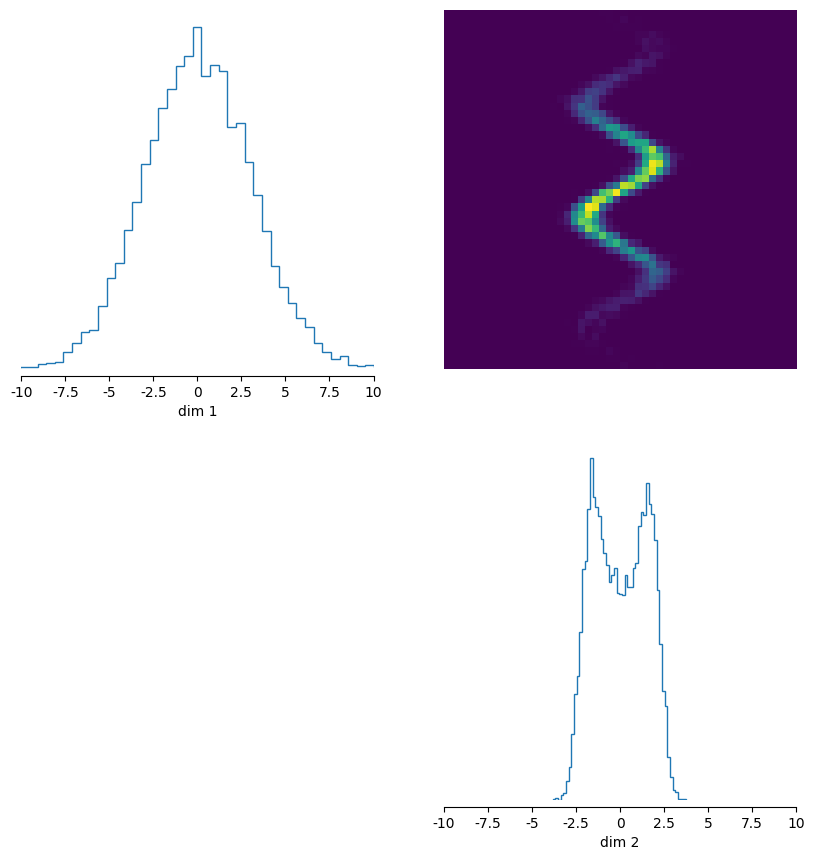

In [5]:
pairplot(np.array(data[:, :, 0]), limits=[[-10, 10], [-10, 10], [-10, 10]])

In [6]:
key = jrandom.PRNGKey(0)

In [7]:
from probjax.nn.helpers import TimeEmbedding

In [8]:
def model(t,x , node_ids, condition_mask):
    dim = 100

    #x = (x - mean)/std

    x = x.reshape(x.shape[0], -1)
    t = t.reshape(-1,1)

    embedding_net = hk.Linear(dim)
    embedding_time = TimeEmbedding(dim)



    model = hk.nets.MLP([200, 200, 200, T_max])

    value_embed = embedding_net(x)
    time_embed = embedding_time(t)
 
    x_encoded = jnp.concatenate([value_embed, time_embed], axis=1)
    #x_encoded = value_embed + time_embed

    h = model(x_encoded)

    return h.reshape(h.shape[0], T_max, 1)


In [9]:

def model(t, x, node_ids, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions
    dim = 200
    embedding_net = hk.Linear(dim)
    embedding_id_nets = hk.Embed(T_max, dim)
    embedding_time = TimeEmbedding(dim)
    embedding_condition_mask = hk.Embed(2**T_max, dim)

    model = Transformer(num_heads=2, num_layers=5, attn_size=dim, dropout_rate=0.0, widening_factor=2)


    value_embeddings = embedding_net(x)
    id_embeddings = embedding_id_nets(node_ids)
    time_embeddings = embedding_time(t.reshape(-1,1,1))
    condition_embedding = embedding_condition_mask(condition_mask)
    
    x_encoded = value_embeddings + id_embeddings + time_embeddings + condition_embedding

    
    
    # Encode
    h = model(x_encoded)

    # Decode
    h_t = jnp.concatenate([time_embeddings, h], axis=-1)
    out = hk.nets.MLP([dim, dim, 1])(h_t)

    out = out * (1-condition_mask.reshape(-1,T_max,1))
    return out


In [10]:

def model(t, x, node_ids, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions
    dim = 200
    _dim = dim // 4
    embedding_net = hk.nets.MLP([dim, _dim])
    embedding_id_nets = hk.Embed(T_max, _dim)
    embedding_time = hk.Sequential([TimeEmbedding(_dim), hk.nets.MLP([_dim, _dim])])
    embedding_condition_mask = hk.Embed(2**T_max, _dim)

    # Positional embedding

    model = Transformer(num_heads=2, num_layers=4, attn_size=dim, dropout_rate=0.0, widening_factor=2)


    value_embeddings = embedding_net(x)
    id_embeddings = embedding_id_nets(node_ids)
    id_embeddings = jnp.broadcast_to(id_embeddings, value_embeddings.shape)
    time_embeddings = embedding_time(t.reshape(-1,1,1))
    time_embeddings = jnp.broadcast_to(time_embeddings, value_embeddings.shape)
    condition_embedding = embedding_condition_mask(condition_mask)
    condition_embedding = jnp.broadcast_to(condition_embedding, value_embeddings.shape)
    


    x_encoded = jnp.concatenate([value_embeddings, id_embeddings, time_embeddings, condition_embedding], axis=-1)

    #x_encoded = embedding_positional(x_encoded)
    
    
    # Encode
    h = model(x_encoded)

    # Decode
    h_t = jnp.concatenate([time_embeddings, h], axis=-1)
    out = hk.nets.MLP([dim, dim, 1])(h_t)

    out = out * (1-condition_mask.reshape(-1,len(node_ids),1))
    return out


In [42]:

def model(t, x, node_ids, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions
    dim = 20
    _dim = dim // 2
    embedding_net = hk.nets.MLP([dim, _dim])
    embedding_id_nets = hk.Embed(T_max, _dim)
    embedding_time = hk.Sequential([TimeEmbedding(_dim), hk.nets.MLP([_dim, _dim])])
    

    # Positional embedding

    model = Transformer(num_heads=1, num_layers=3, attn_size=dim, dropout_rate=0.0, widening_factor=2)


    value_embeddings = embedding_net(x)
    id_embeddings = embedding_id_nets(node_ids)
    id_embeddings = jnp.broadcast_to(id_embeddings, value_embeddings.shape)
    time_embeddings = embedding_time(t.reshape(-1,1,1))
    time_embeddings = jnp.broadcast_to(time_embeddings, value_embeddings.shape)
    condition_embedding = hk.get_parameter("condition_embedding", shape=(dim,), init=hk.initializers.RandomNormal(stddev=0.1))
    condition_embedding = condition_embedding.reshape(1,1, -1) * condition_mask.reshape(-1, T_max,1)
    


    x_encoded = jnp.concatenate([value_embeddings, id_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding
        
    # Encode
    h = model(x_encoded)

    # Decode
    h_t = jnp.concatenate([time_embeddings, h], axis=-1)
    out = hk.nets.MLP([dim, dim, 1])(h_t)

    out = out * (1-condition_mask.reshape(-1,len(node_ids),1))
    return out


In [43]:
init, model_fn = hk.transform(model)
params = init(key, jnp.ones(data.shape[0]), data, node_ids, jnp.zeros_like(node_ids))

In [44]:
times = jax.random.uniform(key, (data.shape[0], 1, 1), minval=1e-6, maxval=1.0)
out = model_fn(params, key, times, data, node_ids, jnp.zeros_like(node_ids))

In [45]:
T = 1.
T_min = 1e-6
beta_min = 0.1
beta_max = 10.

def beta(t):
    return beta_min + t * (beta_max - beta_min)

def drift_fn(x, t):
    return -0.5 * (beta(t)) * x

def diffusion_fn(x, t):
    # This migh requrire a square root
    return jnp.sqrt(beta(t)) * jnp.ones_like(x)

def marginal_mean(x0, t):
    phi = jnp.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5*t * beta_min)
    return phi * x0

def marginal_std(x0, t):
    phi = jnp.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min)
    return jnp.sqrt(1 - 1 * phi)

def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = marginal_mean(x0, t) + std * noise
    return x_noised

log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
score_fn = jax.grad(log_prob_fn)

In [46]:
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)


def loss_fn(params, key, batch_size= 128):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data
    times = jax.random.uniform(rng_time, (batch_size, 1, 1), minval=T_min, maxval=1.0)
    batch_xs = generate_data(rng_data, batch_size) # n, T_max, 1

    # Permute sequence -> randomly permute the sequence of data to promote node identification
    ids = jax.random.choice(rng_permute_ids,jnp.array([node_ids, node_ids[::-1]]), shape=(), axis=0)
    batch_xs = batch_xs[:, ids, :]

    # Condition mask -> randomly condition on some data -> Sample more frequently no condition
    condition_mask = jax.random.choice(rng_condition, jnp.array([[0,0], [1,0], [0,1]]), shape=(batch_size, ), p=jnp.array([0.8, 0.1, 0.1]), axis=0)
    condition_mask = condition_mask[..., None]


    # Forward diffusion
    batch_noisy_xs = sbd_forward(rng_sample, batch_xs, times)
    batch_noisy_xs = batch_noisy_xs * (1-condition_mask) + batch_xs * condition_mask # Condition on the data

    score_pred = model_fn(params, rng_model, times, batch_noisy_xs, ids, condition_mask[...,0])
    score_target = score_fn(batch_noisy_xs, times, batch_xs)
    # Weighting function
    # Seems to be important here
    # lam = beta(times) 
    lam = 1-jnp.exp(-0.5 * (beta_max - beta_min) * times**2 - beta_min * times)
    # Loss

    loss = jnp.mean(jnp.sum((1- condition_mask)*lam*(score_pred - score_target) ** 2, axis=-2))
    return loss


@jax.jit
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [47]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [48]:
for _ in range(10):
    l = 0
    for i in range(1000):
        key = jrandom.PRNGKey(i)
        loss, params, opt_state = update(params, key, opt_state)
        l += loss / 1000
    print(l)

1.0373182
0.93847895
0.91801125
0.9075454
0.90010124
0.8949156
0.89031565
0.8873146
0.8846285
0.8827948


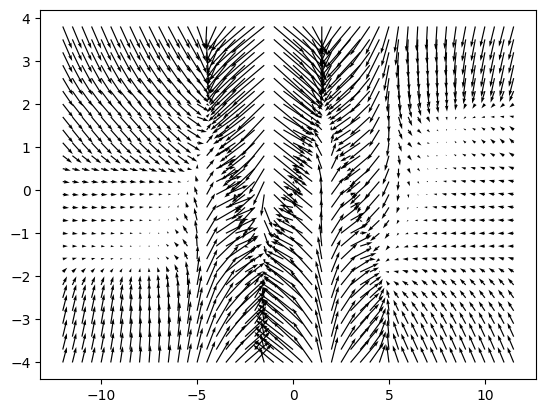

In [18]:
# Check vector field
x, y = jnp.meshgrid(jnp.arange(-12, 12, 0.5), jnp.arange(-4, 4, 0.3))
pos = jnp.dstack((x, y)).reshape(-1, T_max, 1)
vs = model_fn(params, key, jnp.ones((pos.shape[0],1, 1)) * 0.00001, pos, node_ids, jnp.zeros_like(node_ids))

plt.quiver(pos[:, 0], pos[:, 1], vs[:, 0], vs[:, 1], scale=100)

In [19]:
from functools import partial

condition_mask = jnp.array([0,0])
condition_value = jnp.array([0., 0])

def drift_backward(t, x, node_ids=node_ids, condition_mask=condition_mask):
    #t = T - t
    score = model_fn(params, key, t.reshape(-1, 1, 1), x.reshape(-1, len(node_ids), 1), node_ids,condition_mask[:len(node_ids)])
    score = score.reshape(x.shape)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f * (1-condition_mask)
    return f

def diffusion_backward(t,x, node_ids=node_ids,condition_mask=condition_mask):
    #t = T - t
    b =  diffusion_fn(x, t)
    b = b * (1-condition_mask[:len(node_ids)])
    return b

In [20]:
from probjax.utils.sdeint import sdeint

In [21]:


noise = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(jrandom.split(key, (1000,)),lambda t, x: drift_fn(x, t), lambda t, x: diffusion_fn(x,t), data[:1000, :, 0], jnp.linspace(T_min, 1., 200))

# Condition on 0 -> sin(0) = 0!
noise = noise * (1-condition_mask) + condition_value * condition_mask

ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(jrandom.split(key, (1000,)), drift_backward, diffusion_backward, noise[:,-1], jnp.linspace(1.,T_min, 200))

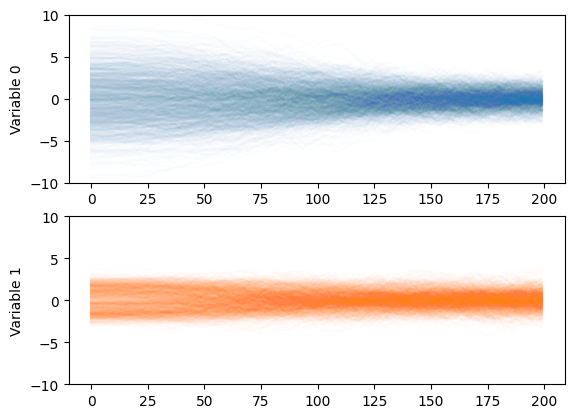

In [22]:
fig, ax = plt.subplots(T_max)
for i in range(T_max):
    _ = ax[i].plot(noise[:, :, i].T, color=f"C{i}", alpha=0.01)
    ax[i].set_ylim(-10, 10)
    ax[i].set_ylabel("Variable {}".format(i))


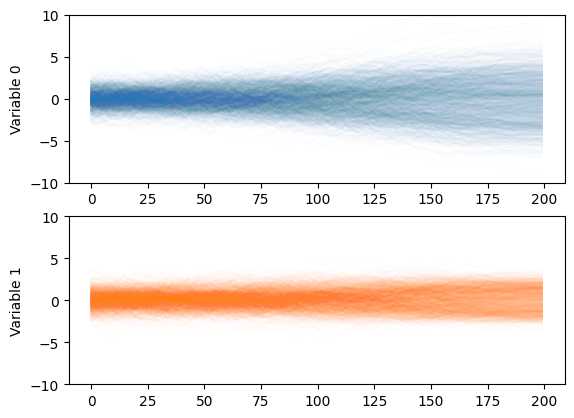

In [23]:
fig, ax = plt.subplots(T_max)
for i in range(T_max):
    _ = ax[i].plot(ys[:, :, i].T, color=f"C{i}", alpha=0.01)
    ax[i].set_ylim(-10, 10)
    ax[i].set_ylabel("Variable {}".format(i))


In [24]:

def sample_fn(key, shape, node_ids=node_ids, time_steps=500, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.)
    x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, node_ids, condition_mask), lambda t, x: diffusion_backward(t, x, node_ids, condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

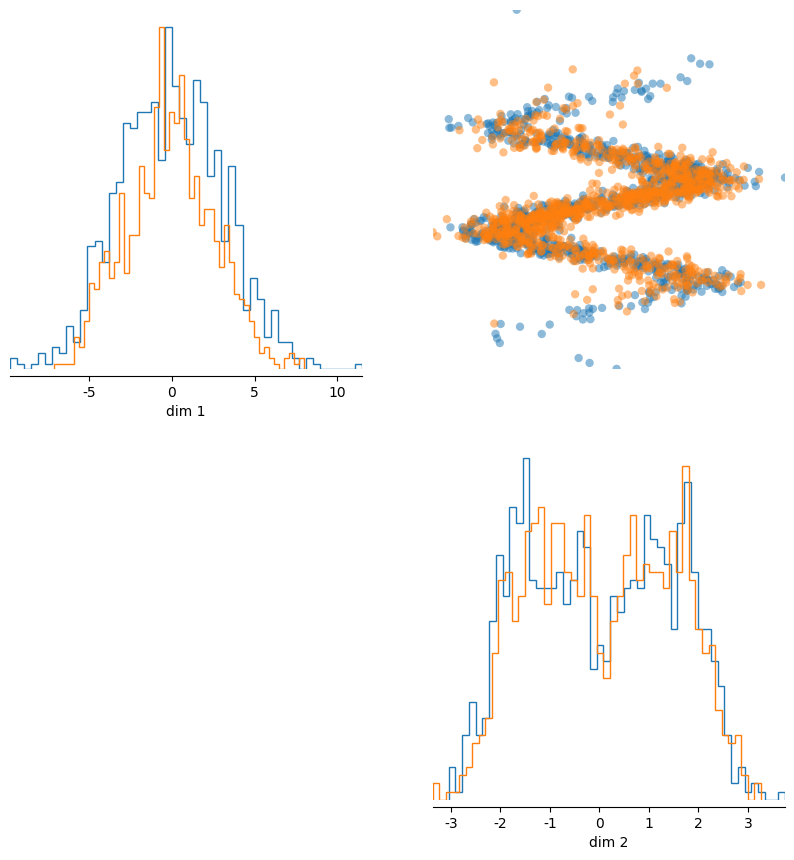

In [25]:

samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=condition_mask, condition_value=condition_value)
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

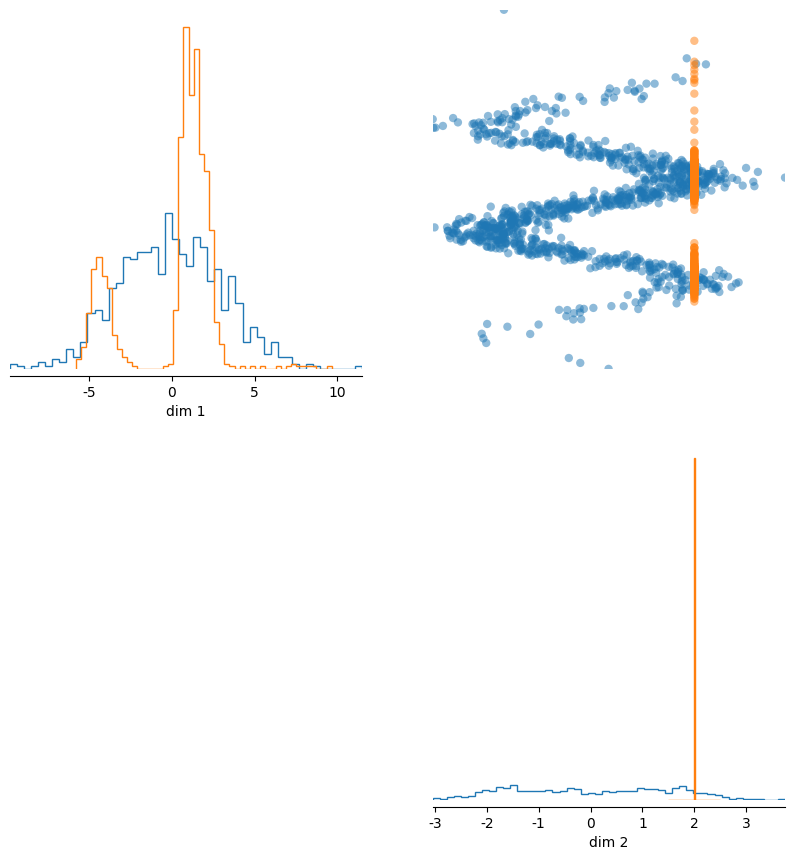

In [26]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,1]), condition_value=jnp.array([0., 2.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

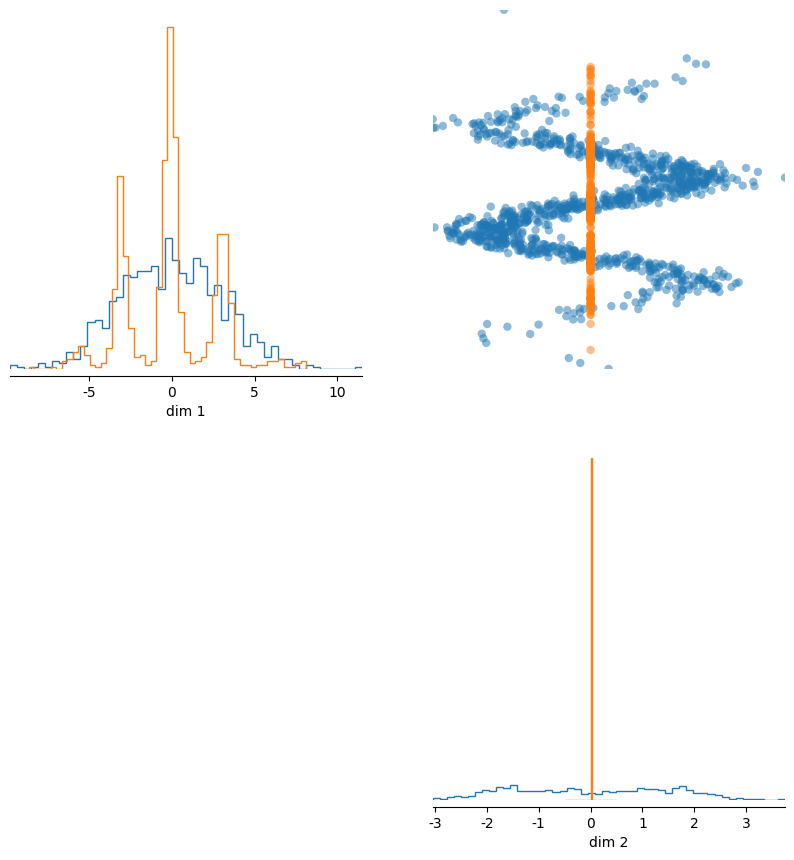

In [27]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,1]), condition_value=jnp.array([0., 0.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

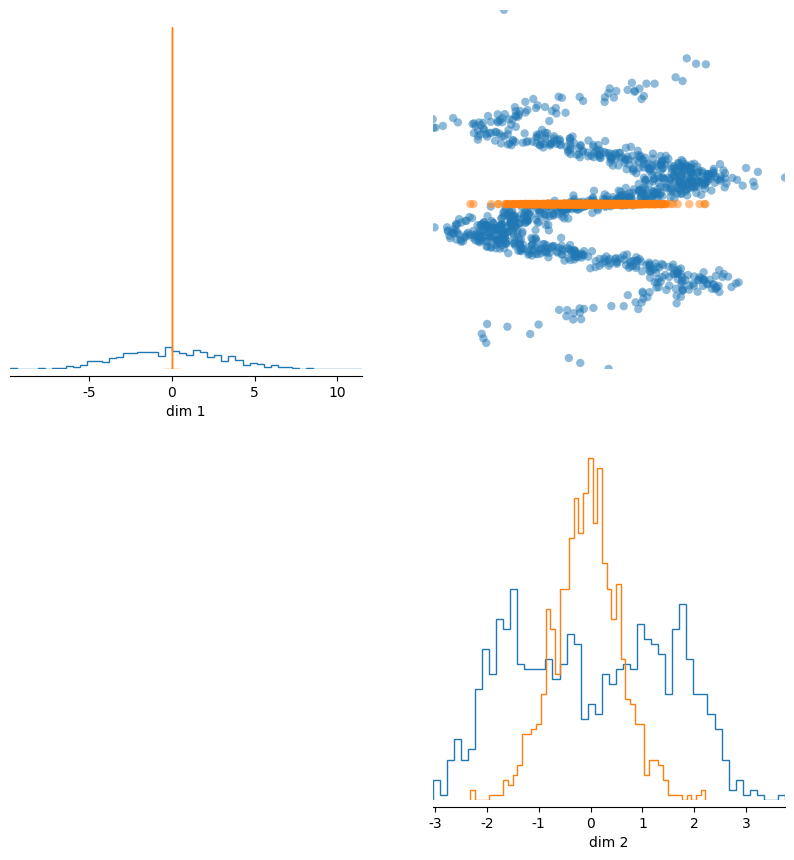

In [28]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([1,0]), condition_value=jnp.array([0., 2.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

In [29]:
from sbi.analysis import pairplot
import numpy as np
condition_mask = jnp.array([0,0])

samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=jnp.array([1]))
_ = plt.hist(np.array(samples[...,-1, 1]).flatten(), bins=100)

InconclusiveDimensionOperation: Cannot divide evenly the sizes of shapes (1,) and (-1, 2, 1)